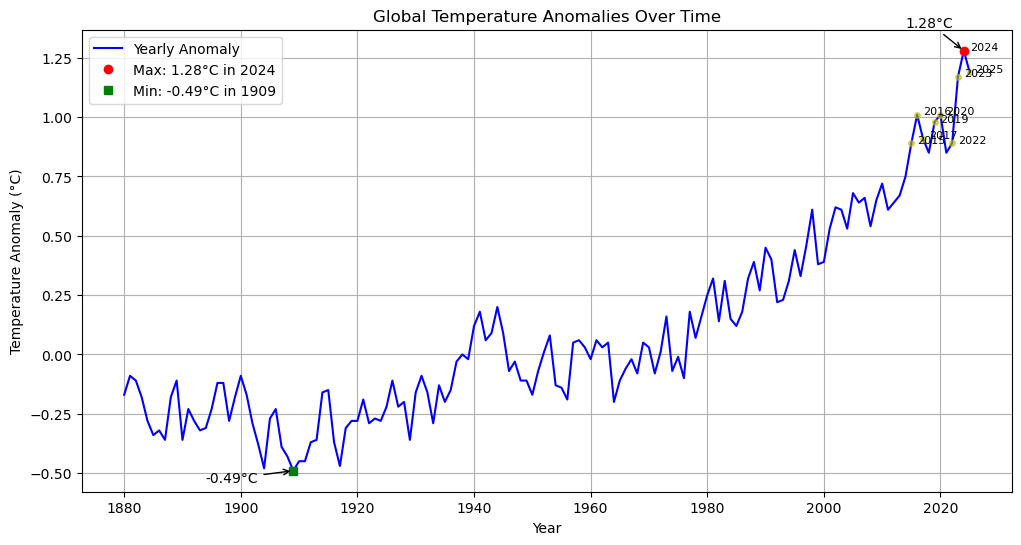

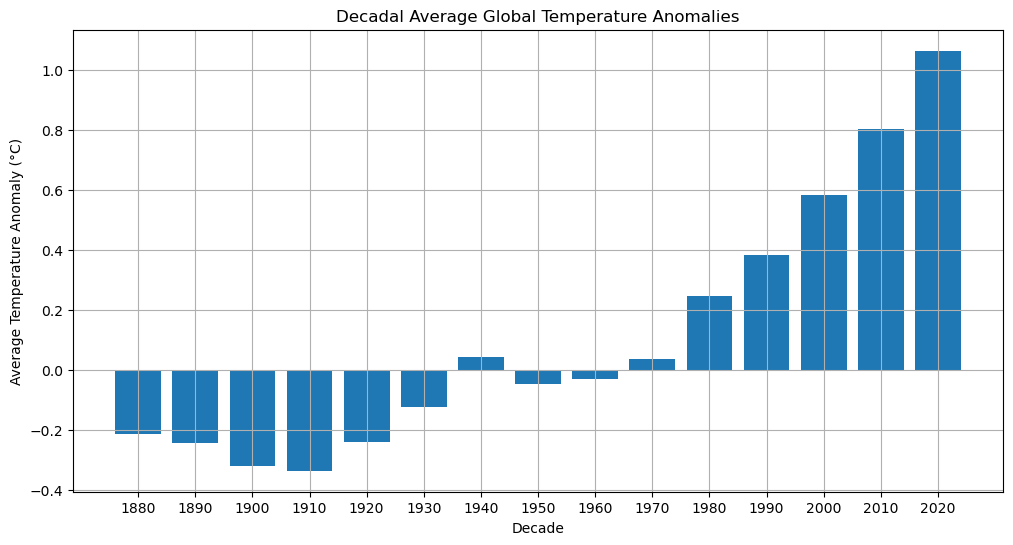

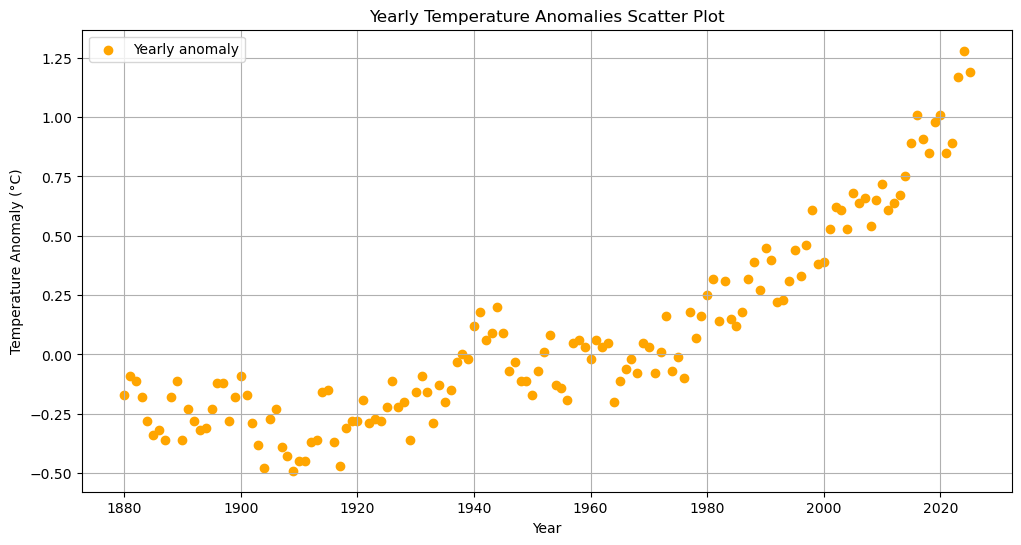

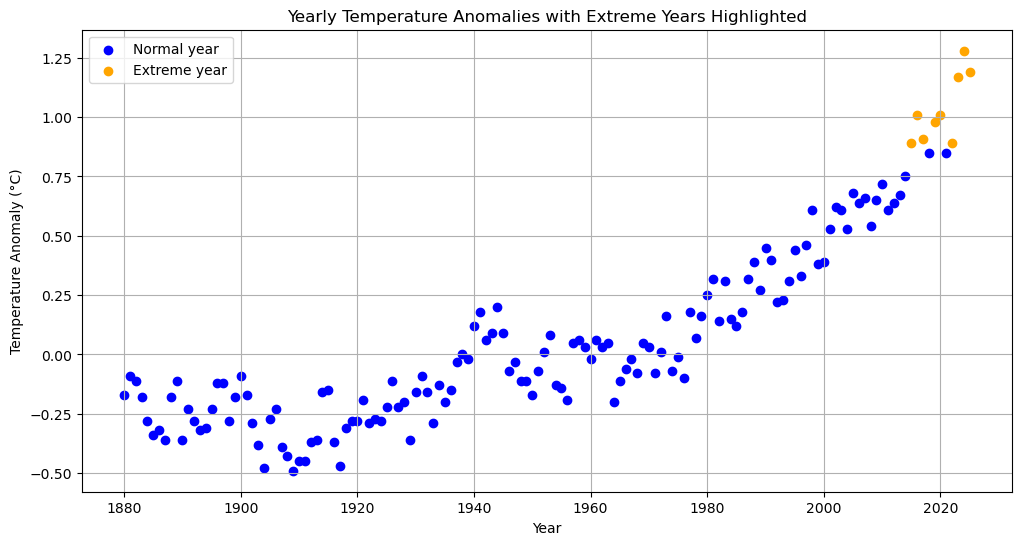

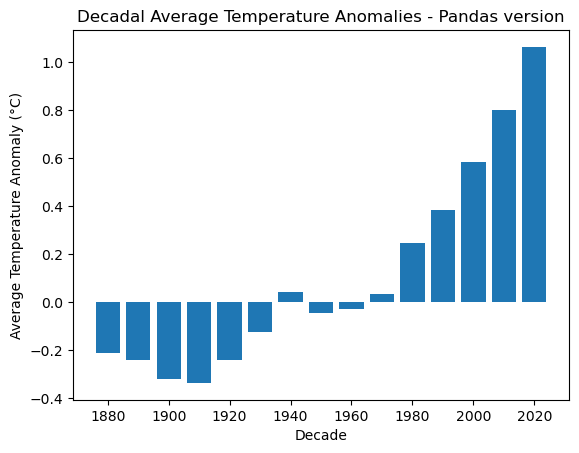

MSE: 0.037, RMSE: 0.193


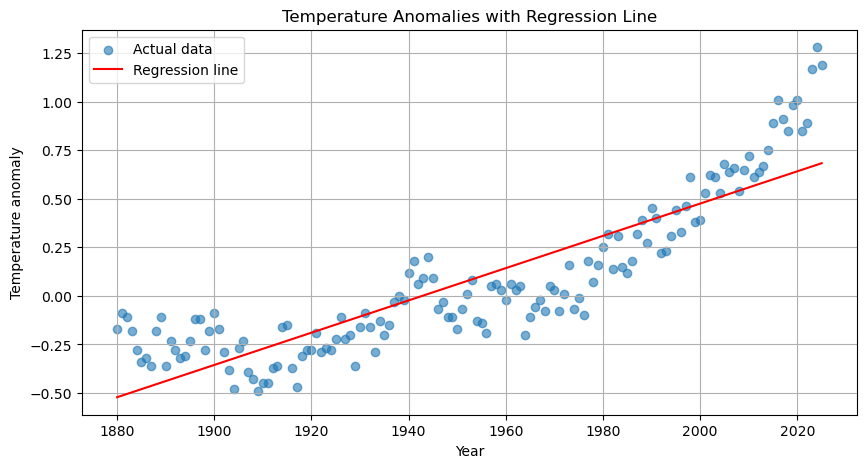

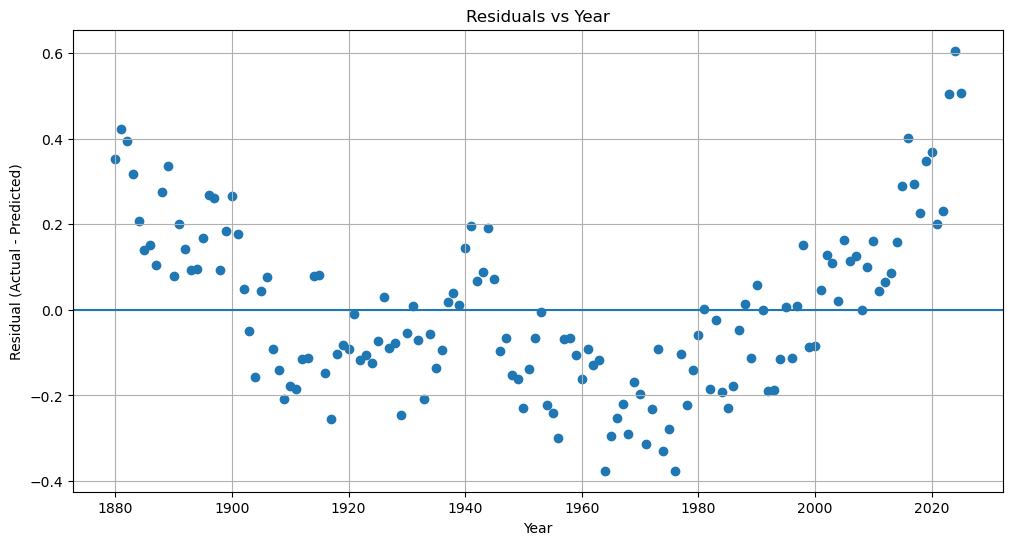

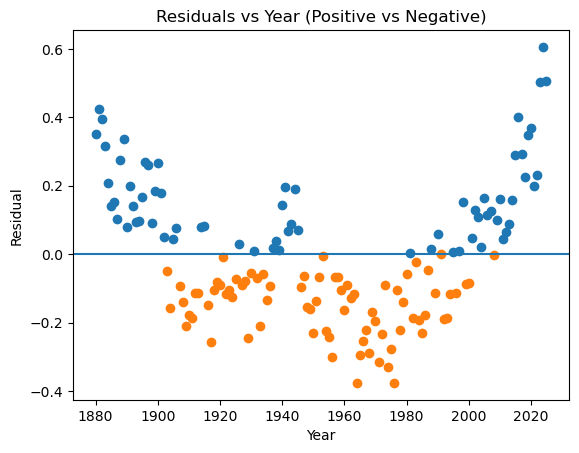

MSE (test): 0.068, RMSE (test): 0.261


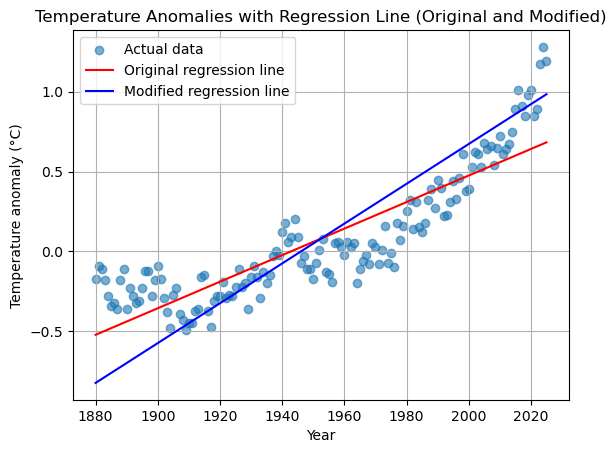

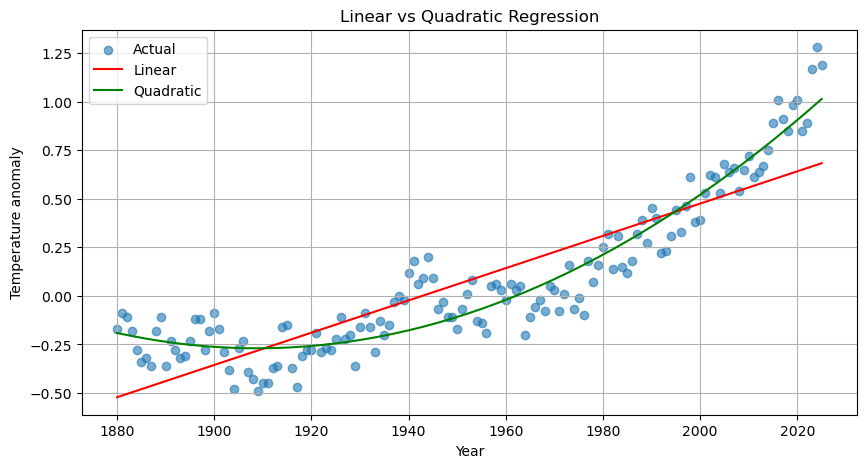

Linear MSE: 0.037350123886283955
Quadratic MSE: 0.0145496903649579
Linear RMSE: 0.1932618014152925
Quadratic RMSE: 0.12062209733277689


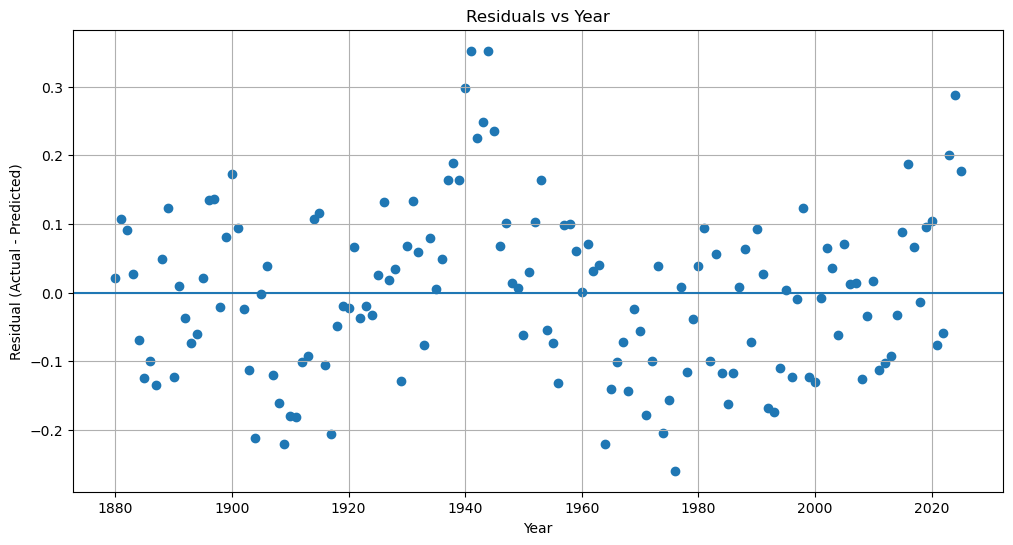

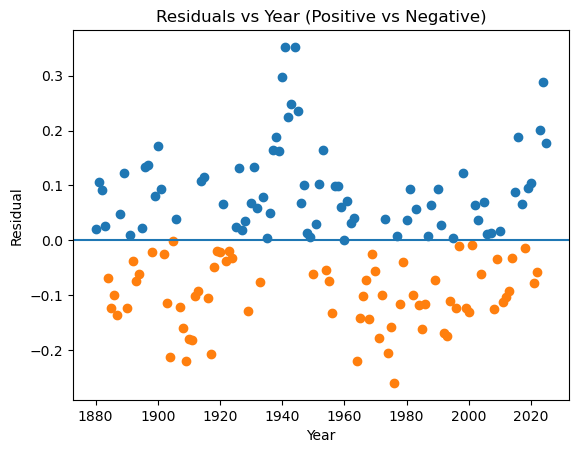

In [1]:
import csv
import logging
import math
import matplotlib.pyplot as plt
import pandas as pd    #common shortening
import numpy as np

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='temperature_analysis.log',
    filemode='a'
)

# ===========================
# Data Loading and Extraction
#============================

def load_temperature_csv(filename):
    """Load NASA GISTEMP CSV into a list of dictionaries."""

    total_rows = 0              #Counts number of rows imported
    missing_year = 0            #Counts number of mussing years
    missing_anomaly = 0         #Counts number of missing data values
    
    data = []  # We'll store each row as a dictionary
    
    try:
        with open(filename, 'r') as file:
            next(file)     #Skips first row in csv file, which contains a header, not column names
            reader = csv.DictReader(file)
            
            for row in reader:  # Process each row one by one
                total_rows += 1  #Adds 1 to the count of number of rows
                
                # Step 1: Convert Year to integer safely
                try:
                    row['Year'] = int(row['Year'])
                except ValueError:
                    row['Year'] = None  # If invalid, mark as None
                    missing_year += 1   #Adds 1 to missing year count
                    
                # Step 2: Convert J-D (yearly anomaly) to float safely
                try:
                    row['J-D'] = float(row['J-D'])
                except ValueError:
                    row['J-D'] = None     # If invalid, mark as None
                    missing_anomaly += 1  #Adds 1 to missing anomaly count
                    
                # Step 3: Append the processed row to the data list
                data.append(row)
    
    except FileNotFoundError:      #Logs an error if file can't be opened
        logging.error(f"File {filename} not found")
        return []
    
    if not data:                   #Logs an error if dataset is empty
        logging.warning(f"No valid data found in {filename}")

    logging.info(f"Total rows loaded: {total_rows}")             #Logs number of rows
    logging.info(f"Missing Year values: {missing_year}")         #Logs number of missing years
    logging.info(f"Missing anomaly values: {missing_anomaly}")   #Logs number of missing anomalies
    
    return data     #Stores the loaded and converted data as 'data'

def extract_years_and_anomalies(dataset):
    """Extract aligned lists of years and anomaly values."""

    years = []       #Two lists to hold values that are also 
    anomalies = []   #x-axis and y-axis values in the plots

    for record in dataset:
        year = record['Year']
        value = record['J-D']

        if year is not None and value is not None:
            years.append(year)
            anomalies.append(value)

    return years, anomalies

# ================
# Basic Statistics
# ================

def compute_average(values):
    """Calculates the average temperature anomaly."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average

def compute_mean(values):
    """Calculates the average temperature anomaly."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average

def compute_std(values):
    """Compute sample standard deviation."""
    
    clean_values = []
    
    for value in values:
        if value is not None:
            clean_values.append(value)

    n = len(clean_values)
    if n < 2:
        logging.warning(f"Not enough valid data to compute standard deviation.")
        return None
    mean = sum(clean_values) / n
    variance = sum((x - mean) ** 2 for x in clean_values) / (n - 1)  # sample SD

    return math.sqrt(variance)

# ========================
# Data Analysis (Features)
# ========================

def find_max_anomaly(dataset):
    """Calculates the maxiumum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    max_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if max_record is None or value > max_record['J-D']:
            max_record = record

    return max_record    

def find_min_anomaly(dataset):
    """Calculates the minimum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    min_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if min_record is None or value < min_record['J-D']:
            min_record = record

    return min_record

def detect_anomalies(dataset):
    """Return records with statistically extreme temperature anomalies."""
    
    temp_anomalies = []

    for record in dataset:
        if record['J-D'] is not None:
            temp_anomalies.append(record['J-D'])     #Appends value (J-D) only to the list

    mean = compute_average(temp_anomalies)
    std = compute_std(temp_anomalies)

    if mean is None or std is None:
        logging.warning("Cannot compute anomalies due to insufficient data.")
        return []

    extreme_records = []     #Creates a list for all anomalies that have a very high standard deviation from baseline

    for record in dataset:
        value = record['J-D']

        if value is None:
            continue

        if abs(value - mean) > 2 * std:    #abs = absolute value from zero, so will be 8 if (value-mean) = 8 or -8
            extreme_records.append(record)    #Appends whole record to the list so that the year is also extractable.

    logging.info(f"Detected {len(extreme_records)} extreme years")   #Logs number of extreme anomaly years

    return extreme_records
     
def compute_decadal_averages(dataset):
    """Compute average anomaly per decade."""
    
    decade_data = {}

    for record in dataset:
        year = record['Year']
        value = record['J-D']

        if year is None or value is None:
            continue

        decade = (year // 10) * 10  # e.g. 1998 → 1990   # // means divide by 10 and rounds to an integer (not a decimal)

        if decade not in decade_data:    #If the decade isn’t in the dictionary, create a list.
            decade_data[decade] = []     #If it is there, append the value to the relevant decade list (eg 2020s)

        decade_data[decade].append(value)

    # Now compute averages
    decade_averages = {}

    for decade in decade_data:
        values = decade_data[decade]       #Gives a list of all valid J-D anomaly values for that decade [0.65, 0.72, 0.8..]
        decade_averages[decade] = compute_average(values)     #Calculates the average value for the values in the deacde list

    logging.info(f"Computed decadal averages for {len(decade_averages)} decades")
    logging.info("Decadal averages computed and prepared for plotting")
    
    return decade_averages

def extract_decade_lists(decade_averages):

    values = []     #Converts the dictionary to an ordered list
    decades = sorted(decade_averages.keys())   #Gives all the keys in the dictionary (in this case the decade names) sorted 1990, 2000, 2010..
    
    for d in decades:   #'d' being each decade
        value = decade_averages[d]   #Get the average J-D value for that decade
        values.append(value)   
    return decades, values

def generate_modified_model(years, m, mean_x, mean_y, factor=1.5):
    m_test = m * factor
    b_test = mean_y - m_test * mean_x
    predicted_test = predict(years, m_test, b_test)
    return m_test, b_test, predicted_test
    
# ========================
# Visualisation (General)
# ========================

def plot_temperature_trend(years, anomalies, max_record, min_record, extreme_records):
    """Plots time_series of global temp anomalies using Matplotlib"""
    """ with highlighted max and min points"""

    #Create temporary variables for max and min values and years (for readability)
    max_year = max_record['Year']
    max_value = max_record['J-D']
    
    min_year = min_record['Year']
    min_value = min_record['J-D']

    #Create the plot, using Matplotlib
    plt.figure(figsize=(12,6))    #Controls size of plot window, if not included there is a default size

    #Line plot of anomalies
    plt.plot(years, anomalies, label='Yearly Anomaly', color='blue')   #Line label in legend, color = line colour

    # Plot extreme anomaly points  (before max and min, or they will cover max)
    for record in extreme_records:
        plt.plot(record['Year'], record['J-D'], 'yo', alpha=0.6, markersize=4)  # yellow circle, transparent, small size

    for record in extreme_records:
        plt.annotate(f"{record['Year']}",
                     xy=(record['Year'], record['J-D']),
                     xytext=(record['Year'] + 1, record['J-D']),
                     fontsize=8)
    
    #Max anomaly plot
    plt.plot(max_year, max_value, 'ro', label=f'Max: {max_value}°C in {max_year}') #Adds marker at max value 'ro' = red circle

    plt.annotate(f'{max_value}°C', xy=(max_year, max_value),        #Adds a pont for the max anomaly value
             xytext=(max_year-10, max_value+0.1),                   #Determines where the spot's label will appear
             arrowprops=dict(facecolor='black', arrowstyle='->'))   #Deterimes colour and style of arrow

    # Min anomaly point
    plt.plot(min_year, min_value, 'gs', label=f'Min: {min_value}°C in {min_year}')   #Adds marker at min value 'gs' = green square
    plt.annotate(f'{min_value}°C',
                 xy=(min_year, min_value),
                 xytext=(min_year-15, min_value-0.05),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
 
    #Labels, legeng, grid
    plt.xlabel("Year")                                  #x-axis label
    plt.ylabel("Temperature Anomaly (°C)")              #y-axis label
    plt.title("Global Temperature Anomalies Over Time") #Graph title
    plt.grid(True)                                      #Shows gridlines
    plt.legend()                                        #Shows legend
    plt.savefig("temperature_trend.png")                #Saves the graph
    plt.show()                                          #Display the plot

def plot_scatter(years, anomalies):
    """Plot yearly temperature anomalies as a scatter plot."""
    
    plt.figure(figsize=(12,6))
    plt.scatter(years, anomalies, color='orange', label='Yearly anomaly')
    plt.xlabel("Year")
    plt.ylabel("Temperature Anomaly (°C)")
    plt.title("Yearly Temperature Anomalies Scatter Plot")
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_anomalies-scatter-plot.png", dpi=300)  
    plt.show()

def plot_anomalies_with_extremes(years, anomalies):
    """
    Plots yearly temperature anomalies and highlights extreme years.

    Inputs:
    - years: list of years
    - anomalies: list of temperature anomaly values
    - mean: average anomaly
    - std: standard deviation of anomalies
    """
    mean = compute_average(anomalies)
    std = compute_std(anomalies)

    normal_years = []
    normal_anomalies = []
    extreme_years = []
    extreme_anomalies = []

    for year, value in zip(years, anomalies):  # loop over each year and its anomaly
        if abs(value - mean) > 2 * std:        # check if it's extreme
            extreme_years.append(year)
            extreme_anomalies.append(value)
        else:
            normal_years.append(year)
            normal_anomalies.append(value)

    # Create the plot
    plt.figure(figsize=(12,6))
    
    # Plot normal years
    plt.scatter(normal_years, normal_anomalies, color='blue', label='Normal year')
    
    # Plot extreme years
    plt.scatter(extreme_years, extreme_anomalies, color='orange', label='Extreme year')

    # Labels and title
    plt.xlabel("Year")
    plt.ylabel("Temperature Anomaly (°C)")
    plt.title("Yearly Temperature Anomalies with Extreme Years Highlighted")
    plt.legend()
    plt.grid(True)
    plt.savefig("anomalies_with_extremes.png", dpi=300)
    plt.show()

def plot_decadal_averages(decades, averages):
    """Plot decadal average anomalies as a bar chart."""
    
    plt.figure(figsize=(12,6))

    plt.bar(decades, averages, width=8)   #Plot bar chart, decades=x-axis, averages=y-axis, 8 wide
    plt.xticks(decades)                   #Centres labels under the bars
    
    plt.xlabel("Decade")
    plt.ylabel("Average Temperature Anomaly (°C)")
    plt.title("Decadal Average Global Temperature Anomalies")

    plt.grid(True)
    plt.savefig("decadal_avg_anomalies.png", dpi=300)  
    plt.show()

def plot_decadal_averages_pandas(filename):
    """
    Load temperature anomaly CSV with pandas, clean it, compute decadal averages,
    and plot a bar chart of decadal average anomalies.

    First attempt at using pandas.
    
    Inputs:
    - filename: path to the CSV file
    """

    # Load and clean data
    df = pd.read_csv("temperature_anomalies.csv", skiprows=1)   #Cretaes a table, first row contains headers, not data

    df['J-D'] = pd.to_numeric(df['J-D'], errors='coerce')     #Cleans the data (deals with invalid cells)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')   #errors='coerce' converts invalid values → NaN (pandas version of None)

    valid_df = df.dropna(subset=['Year', 'J-D']).copy()  #Only keep rows where Year and J-D are valid

    # Compute summary stats
    avg = valid_df['J-D'].mean()        #Computes average directly
    std = valid_df['J-D'].std()         #Computes standard deviation directly

    max_row = valid_df.loc[valid_df['J-D'].idxmax()]   #Finds max and min values directly
    min_row = valid_df.loc[valid_df['J-D'].idxmin()]

    # Compute summary stats
    valid_df['Decade'] = (valid_df['Year'] // 10) * 10      #Create decade column
    decade_avg = valid_df.groupby('Decade')['J-D'].mean()   # Group and average

    decades = decade_avg.index            #Convert for Plotting
    avg_values = decade_avg.values

    # Plot decadal averages
    plt.bar(decades, avg_values, width=8)  #Plot (Bar Chart)
    plt.xlabel("Decade")
    plt.ylabel("Average Temperature Anomaly (°C)")
    plt.title("Decadal Average Temperature Anomalies - Pandas version")
    plt.savefig("decadal_avg_anomalies_pandas.png", dpi=300)
    plt.show()

    # Return cleaned DataFrame and decadal averages in case we want them later
    return valid_df, decade_avg

# =================
# Linear Regression
# =================

def fit_linear_regression(years, anomalies):  #Regression parameter calculation
    mean_x = compute_mean(years)
    mean_y = compute_mean(anomalies)

    products = []
    x_squares = []

    for x, y in zip(years, anomalies):
        dx = x - mean_x
        dy = y - mean_y
        products.append(dx * dy)
        x_squares.append(dx * dx)

    sum_products = sum(products)
    sum_x_squares = sum(x_squares)

    m = sum_products / sum_x_squares
    b = mean_y - m * mean_x

    return m, b, mean_x, mean_y
    
def predict(years, m, b):           #Prediction generation
    predicted_values = []

    for x in years:
        y_hat = m * x + b
        predicted_values.append(y_hat)

    return predicted_values

def compute_mse(years, anomalies, m, b):    #Evaluation metrics (MSE/RMSE calculations) plus MSE test model
    squared_errors = []

    for x, y in zip(years, anomalies):
        y_hat = m * x + b              # Or alternatively -  y_hat = m * (x - mean_x) + mean_y
        error = y - y_hat              #The residual - difference between predicted value (y_hat) and actual measured value (y)
        squared_error = error ** 2     #Errors are squared so that +ve and -ve erors don't cancel out
        squared_errors.append(squared_error)   
   
    mse = sum(squared_errors) / len(squared_errors)   #Mean squared error (MSE) - the average of the squared errors in °C²
    rmse = math.sqrt(mse)                             #Square root of MSE, gives the error in °C
    
    return mse, rmse

def compute_residuals(years, anomalies, m, b):     #Residual analysis - residuals, positive/negative split  
    
    residuals = []

    for x, y in zip(years, anomalies):
        y_hat = m * x + b
        residual = y - y_hat      #Residual same as error (difference between y_hat and y)
        residuals.append(residual)

    return residuals

def split_residuals(years, residuals):
    
    positive_years = []           #For replotting residuals, making positive and negative clearer to see
    positive_residuals = []

    negative_years = []
    negative_residuals = []

    for x, r in zip(years, residuals):   
        if r >= 0:
            positive_years.append(x)
            positive_residuals.append(r)
        else:
            negative_years.append(x)
            negative_residuals.append(r)

    return positive_years, positive_residuals, negative_years, negative_residuals

# ===============
# Linear Plotting
# ===============

def plot_regression(years, anomalies, predicted):
            
    plt.figure(figsize=(10,5))

    plt.scatter(years, anomalies, label="Actual data", alpha=0.6)
    plt.plot(years, predicted, color="red", label="Regression line")

    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly")
    plt.title("Temperature Anomalies with Regression Line")
    plt.legend()
    plt.grid(True)
    plt.savefig("temperature_anomalies_with_regression_line.png", dpi=300)
    plt.show()

def plot_residuals(years, residuals, filename=None):
    #Visualise errors (residuals)
    plt.figure(figsize=(12,6))

    plt.scatter(years, residuals)
    plt.axhline(0)     #Puts horizoatal marker line at y=0
    plt.xlabel("Year")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title("Residuals vs Year")
    plt.grid(True)
    if filename:
        plt.savefig(filename, dpi=300)    #Allows saving to separate files
    plt.show()

def plot_positive_negative_residuals(
    positive_years, positive_residuals,
    negative_years, negative_residuals
    ): 
    #If residuals show a pattern → model is wrong type
    #If residuals are random → model is appropriate

    plt.scatter(positive_years, positive_residuals)
    plt.scatter(negative_years, negative_residuals)

    plt.axhline(y=0)
    plt.title("Residuals vs Year (Positive vs Negative)")
    plt.xlabel("Year")
    plt.ylabel("Residual")
    plt.savefig("positive_negative_residuals_linear.png") 
    plt.show()

def plot_model_comparison(years, anomalies, predicted_values, predicted_test):

    plt.scatter(years, anomalies, label="Actual data", alpha=0.6)
    plt.plot(years, predicted_values, color="red", label="Original regression line")
    plt.plot(years, predicted_test, color="blue", label="Modified regression line")
    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly (°C)")
    plt.title("Temperature Anomalies with Regression Line (Original and Modified)")
    plt.legend()
    plt.grid(True)
    plt.savefig("anomalies_modified_regression_line.png") 
    plt.show()

# =====================
# Quadratic  Regression
# =====================

def fit_quadratic_regression(years, anomalies):  #Quadratic regression parameter calculation
    
    N = len(years)
 
    #Find values for Σx, Σx², Σx³, Σx^4, Σy, Σxy and Σx²y to use later in calculations
    sum_x = 0
    sum_x2 = 0
    sum_x3 = 0
    sum_x4 = 0
    sum_y = 0
    sum_xy = 0
    sum_x2y = 0

    for x, y in zip(years, anomalies):
        x2 = x * x
        x3 = x2 * x
        x4 = x3 * x

        sum_x += x
        sum_x2 += x2
        sum_x3 += x3
        sum_x4 += x4
        sum_y += y
        sum_xy += x * y
        sum_x2y += x2 * y

    # Build coefficients
    A = [
        [sum_x4, sum_x3, sum_x2],
        [sum_x3, sum_x2, sum_x],
        [sum_x2, sum_x,  N]
    ]

    B = [sum_x2y, sum_xy, sum_y]
    
    # Solve system using basic elimination (manual, readable)
    # We'll use a simple method (Cramer's rule-like approach)

    import numpy as np

    coeffs = np.linalg.solve(A, B)

    a, b, c = coeffs

    return a, b, c

def predict_quadratic(years, a, b, c):
    predicted = []

    for x in years:
        y_hat = a * x * x + b * x + c    #y=ax²+bx+c
        predicted.append(y_hat)

    return predicted

def compute_mse_quadratic(years, anomalies, a, b, c):

    squared_errors = []

    for x, y in zip(years, anomalies):
        y_hat = a * x**2 + b * x + c           
        error = y - y_hat             
        squared_error = error ** 2     
        squared_errors.append(squared_error)   
   
    mse = sum(squared_errors) / len(squared_errors)   
    rmse = math.sqrt(mse)   

    return mse, rmse

def compute_residuals_quadratic(years, anomalies, a, b, c):
    
    residuals = []

    for x, y in zip(years, anomalies):
        y_hat = a * x**2 + b * x + c 
        residual = y - y_hat      #Residual same as error (difference between y_hat and y)
        residuals.append(residual)

    return residuals

def run_quadratic_regression_pipeline(years, anomalies):
    
    # 1. Fit model
    a, b, c = fit_quadratic_regression(years, anomalies)

    # 2. Predictions
    predictions = predict_quadratic(years, a, b, c)

    # 3. Metrics
    mse, rmse = compute_mse_quadratic(years, anomalies, a, b, c)

    # 4. Residuals
    residuals = compute_residuals_quadratic(years, anomalies, a, b, c)

    # 5. Package results (STANDARD FORMAT)
    results = {

        "model": {
            "type": "quadratic_regression",
            "coefficients": {
                "a": a,
                "b": b,
                "c": c
            }
        },

        "metrics": {
            "mse": mse,
            "rmse": rmse
        },

        "predictions": predictions,

        "residuals": residuals
    }

    return results


# ================
# Model Comparison
# ================
    
def plot_model_comparison_full(years, anomalies, predicted_linear, predicted_quadratic):
    plt.figure(figsize=(10,5))

    plt.scatter(years, anomalies, alpha=0.6, label="Actual")
    plt.plot(years, predicted_linear, color="red", label="Linear")
    plt.plot(years, predicted_quadratic, color="green", label="Quadratic")

    plt.xlabel("Year")
    plt.ylabel("Temperature anomaly")
    plt.title("Linear vs Quadratic Regression")
    plt.legend()
    plt.grid(True)
    plt.savefig("quadratic_regression_anomalies.png") 
    plt.show()

# =========================
# CONTROL SECTION
# =========================

# Load Data
temperature_data = load_temperature_csv("temperature_anomalies.csv")

# Extract Time Series
years, anomalies = extract_years_and_anomalies(temperature_data)

# Compute Stats
avg = compute_average(anomalies)
std_dev = compute_std(anomalies)
logging.info(f"Average anomaly: {compute_average(anomalies):.3f}")
logging.info(f"Standard deviation: {std_dev:.3f}")

# Feature Analysis
extreme_records = detect_anomalies(temperature_data)
max_record = find_max_anomaly(temperature_data)
min_record = find_min_anomaly(temperature_data)

decade_averages = compute_decadal_averages(temperature_data)
decades, avg_values = extract_decade_lists(decade_averages)
  

# Plotting
plot_temperature_trend(years, anomalies, max_record, min_record, extreme_records)
plot_decadal_averages(decades, avg_values)
plot_scatter(years, anomalies)
plot_anomalies_with_extremes(years, anomalies) 
valid_df, decade_avg = plot_decadal_averages_pandas("temperature_anomalies.csv")

#Linear Regression Model
m, b, mean_x, mean_y = fit_linear_regression(years, anomalies)

predicted = predict(years, m, b)

mse, rmse = compute_mse(years, anomalies, m, b)
print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}")

residuals = compute_residuals(years, anomalies, m, b)

# Linear Visuals
plot_regression(years, anomalies, predicted)
plot_residuals(years, residuals, "residuals_linear.png")    #Saves linear version to file

pos_y, pos_r, neg_y, neg_r = split_residuals(years, residuals)
plot_positive_negative_residuals(pos_y, pos_r, neg_y, neg_r)

#Model Experiment
m_test = m * 1.5
b_test = mean_y - m_test * mean_x
predicted_test = predict(years, m_test, b_test)
mse_test, rmse_test = compute_mse(years, anomalies, m_test, b_test)
mse_test, rmse_test = compute_mse(years, anomalies, m_test, b_test)

print(f"MSE (test): {mse_test:.3f}, RMSE (test): {rmse_test:.3f}")
plot_model_comparison(years, anomalies, predicted, predicted_test)  

#Quadratic Model
a, b_quad, c = fit_quadratic_regression(years, anomalies)

predicted_quad = predict_quadratic(years, a, b_quad, c)

plot_model_comparison_full(years, anomalies, predicted, predicted_quad)

mse_linear, rmse_linear = compute_mse(years, anomalies, m, b)
mse_quad, rmse_quad = compute_mse_quadratic(years, anomalies, a, b_quad, c)

print("Linear MSE:", mse_linear)
print("Quadratic MSE:", mse_quad)
print("Linear RMSE:", rmse_linear)
print("Quadratic RMSE:", rmse_quad)

residuals_quad = compute_residuals_quadratic(years, anomalies, a, b_quad, c)

temp_results = run_quadratic_regression_pipeline(years, anomalies)

#Quadratic Visuals

plot_residuals(years, residuals_quad, "residuals_quadratic.png")   #Saves quadratic version to separate file

pos_y_q, pos_r_q, neg_y_q, neg_r_q = split_residuals(years, residuals_quad)
plot_positive_negative_residuals(pos_y_q, pos_r_q, neg_y_q, neg_r_q)



In [6]:
print(mean_x)
print(mean_y)

1952.5
0.08041095890410968


In [21]:
print(sum_products)
print(sum_x_squares)

2154.69
259332.5


In [3]:
print(mse)
print(rmse)

0.037350123886283955
0.1932618014152925


In [3]:
mean_residual = sum(residuals) / len(residuals)
print(mean_residual)

-2.1784087091269847e-15


In [5]:
predicted_test = []

for x in years:
    y_hat = m_test * x + b
    predicted_test.append(y_hat)

squared_errors_test = []

for x, y in zip(years, anomalies):
    y_hat = m_test * x + b
    error = y - y_hat
    squared_error = error ** 2
    squared_errors_test.append(squared_error)

mse_test = sum(squared_errors_test) / len(squared_errors_test)
print(mse_test)

65.86071761609354


In [ ]:
def model_comparison(years, anomalies):  
    """Model what happens when we make m=1.5"""
    m_test = m * 1.5 
    b_test = mean_y - m_test * mean_x

    predicted_test = []

    for x in years:
        y_hat = m_test * x + b_test
        predicted_test.append(y_hat)

    squared_errors_test = []

    for x, y in zip(years, anomalies):
        y_hat = m_test * x + b_test
        error = y - y_hat
        squared_error = error ** 2
        squared_errors_test.append(squared_error)

    mse_test = sum(squared_errors_test) / len(squared_errors_test)

    return predicted_test

In [9]:
print(mse, rmse)
print(mse_test, rmse_test)


0.037350123886283955 0.1932618014152925
0.06800501644633243 0.260777714627482


In [ ]:
decades = sorted(decade_averages.keys())   #Gives alll the keys in the dictionary (in this case the decade names) sorted 1990, 2000, 2010..

avg_values = []     #Converts the dictionary to an ordered list
for d in decades:   #'d' being each decade
    value = decade_averages[d]   #Get the average J-D value for that decade
    avg_values.append(value)   